# Country Segmentation Using Unsupervised Learning

This notebook walks through a full clustering pipeline on the **Unsupervised Learning on Country Data** dataset from Kaggle.
The goal is to group countries into meaningful segments based on socioeconomic and health indicators, so we can identify which nations are struggling and which are thriving.

### What we'll do here
- Load the raw CSV and clean it up
- Scale the features so clustering algorithms work properly
- Use the Elbow Method to find the right number of clusters
- Run K-Means and evaluate it with silhouette score
- Compare with DBSCAN as a second approach
- Visualize everything with PCA
- Write up observations about what the clusters actually mean

## 1) Install required libraries

Making sure all the packages we need are available in this Colab environment.

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import all the libraries we need

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Upload and load the CSV

Using the Colab upload widget to bring in the `Country-data.csv` file.

In [3]:
try:
    from google.colab import files
    uploaded_file = files.upload()
    fname = list(uploaded_file.keys())[0]
    country_records = pd.read_csv(io.BytesIO(uploaded_file[fname]))
except ModuleNotFoundError:
    # running locally, just read the csv from the same folder
    country_records = pd.read_csv('Country-data.csv')

country_records.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick data inspection

Let's check the shape, data types, and basic statistics before doing anything else.

In [4]:
print('Dataset dimensions:', country_records.shape)
print('---')
display(country_records.head(10))
print('---')
display(country_records.info())
print('---')
display(country_records.describe(include='all').T)

Dataset dimensions: (167, 10)
---


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


---
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


None

---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Verify expected columns

This dataset should contain these features:
- country, child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp

Let me confirm they're all there.

In [5]:
print('Columns found in dataset:', country_records.columns.tolist())

Columns found in dataset: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Data cleaning pipeline

Several things to handle here:
1. Strip whitespace from column names (sometimes CSVs have trailing spaces)
2. Remove duplicate rows
3. Force numeric types on feature columns
4. Fill any missing values with the median of that column

In [6]:
country_records = country_records.copy()

# stripping spaces and lowercasing column names
country_records.columns = [col.strip().lower() for col in country_records.columns]

rows_before = len(country_records)
country_records = country_records.drop_duplicates()
print(f'Dropped {rows_before - len(country_records)} duplicate rows')

# coerce forces bad entries to NaN instead of crashing
for col_name in country_records.columns:
    if col_name != 'country':
        country_records[col_name] = pd.to_numeric(country_records[col_name], errors='coerce')

# using median to fill NaN since mean gets thrown off by outliers
measure_cols = [c for c in country_records.columns if c != 'country']
country_records[measure_cols] = country_records[measure_cols].fillna(
    country_records[measure_cols].median()
)

print('\nNull counts after cleaning:')
print(country_records.isna().sum())

Dropped 0 duplicate rows

Null counts after cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 7) Exploratory Data Analysis

Before jumping into clustering, let's visualize how features correlate and check for outliers.

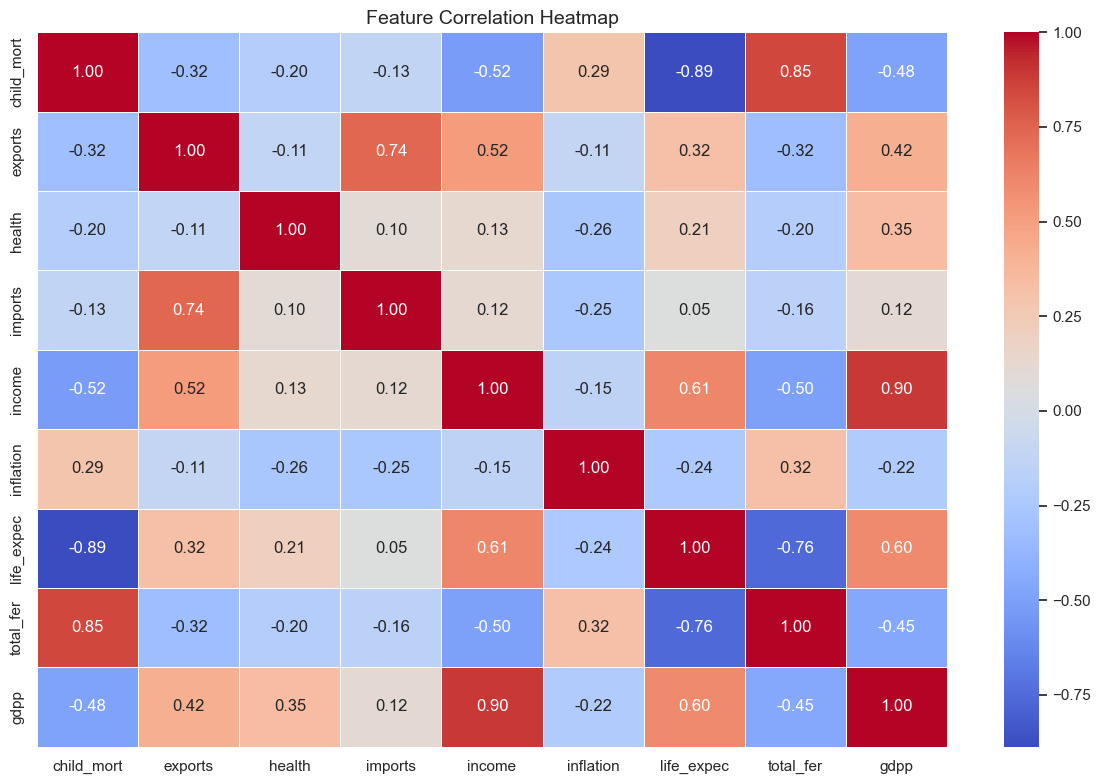

In [7]:
plt.figure(figsize=(12, 8))
corr_mat = country_records.select_dtypes(include=np.number).corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

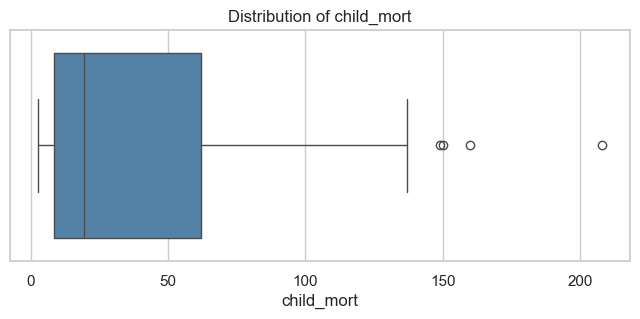

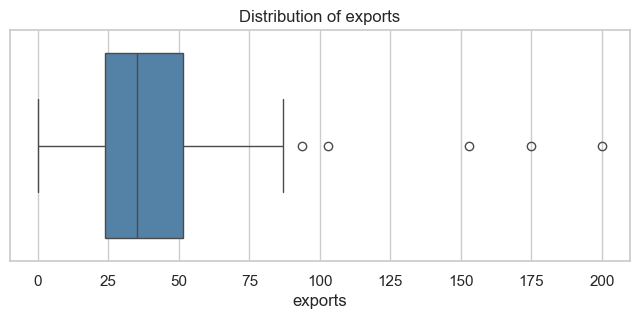

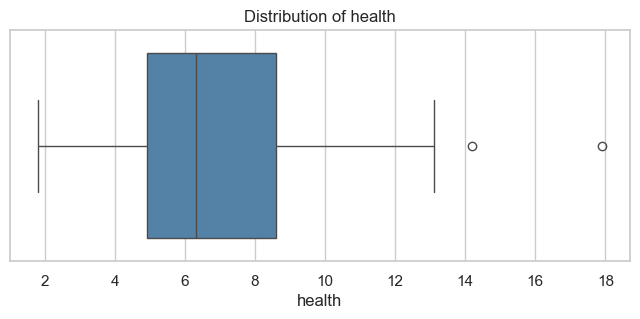

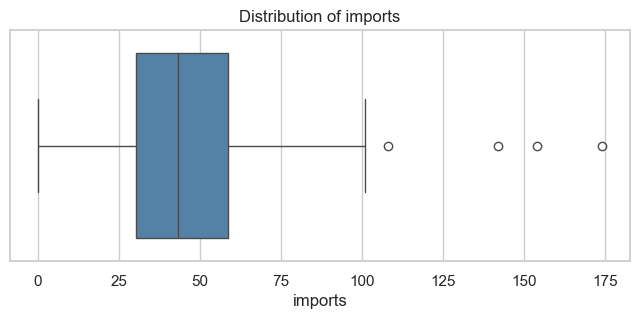

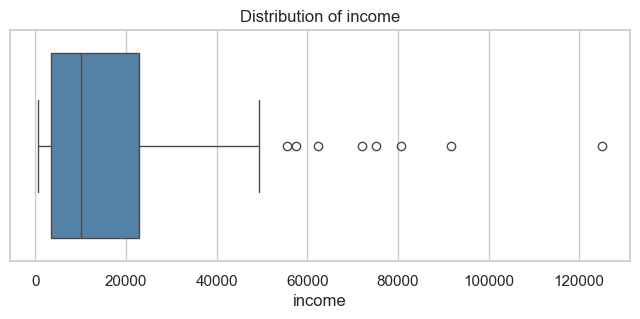

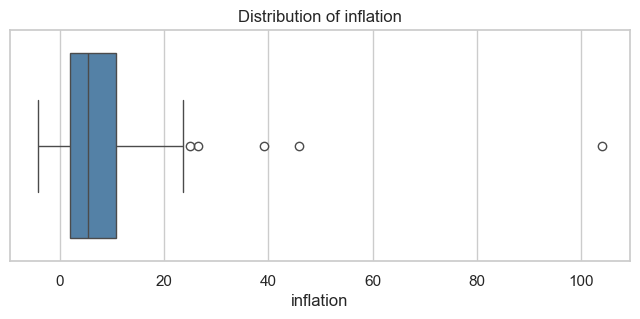

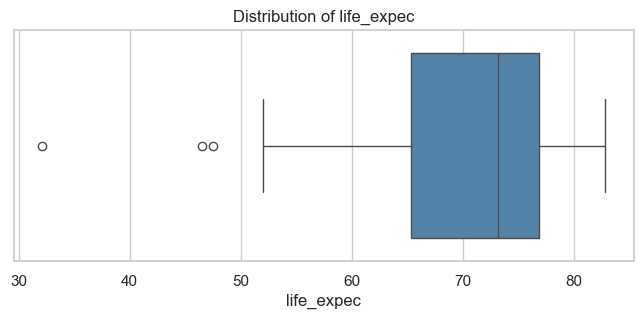

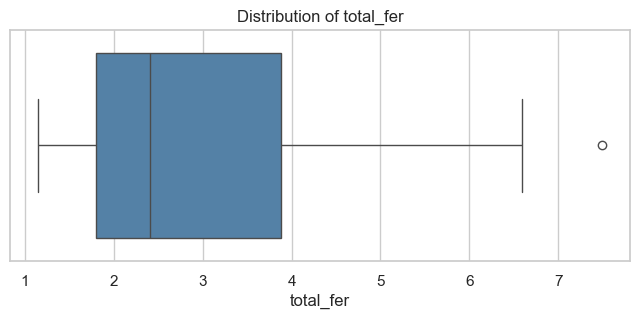

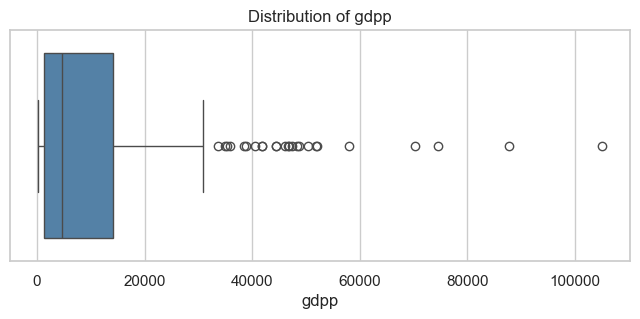

In [8]:
for col_name in measure_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=country_records[col_name], color='steelblue')
    plt.title(f'Distribution of {col_name}')
    plt.show()

## 8) Feature scaling

K-Means relies on distance calculations, so features on different scales (like income in thousands vs inflation in single digits) will mess up the results.
Dropping the country name column first, then standardizing everything with StandardScaler.

In [9]:
# dropping country name — only numeric cols go into the scaler
quant_block = country_records.drop(columns=['country'], errors='ignore')

feat_normalizer = StandardScaler()
normed_matrix = feat_normalizer.fit_transform(quant_block)

print('Scaled matrix shape:', normed_matrix.shape)
print(f'Mean after scaling: {normed_matrix[:, 0].mean():.6f}')  # should be ~0
print(f'Std after scaling: {normed_matrix[:, 0].std():.4f}')    # should be ~1

Scaled matrix shape: (167, 9)
Mean after scaling: -0.000000
Std after scaling: 1.0000


## 9) K-Means — Elbow Method

Testing k from 2 to 10 and tracking the inertia (within-cluster sum of squares) for each.
The idea is to find where adding more clusters stops giving a significant improvement — the "elbow" point.

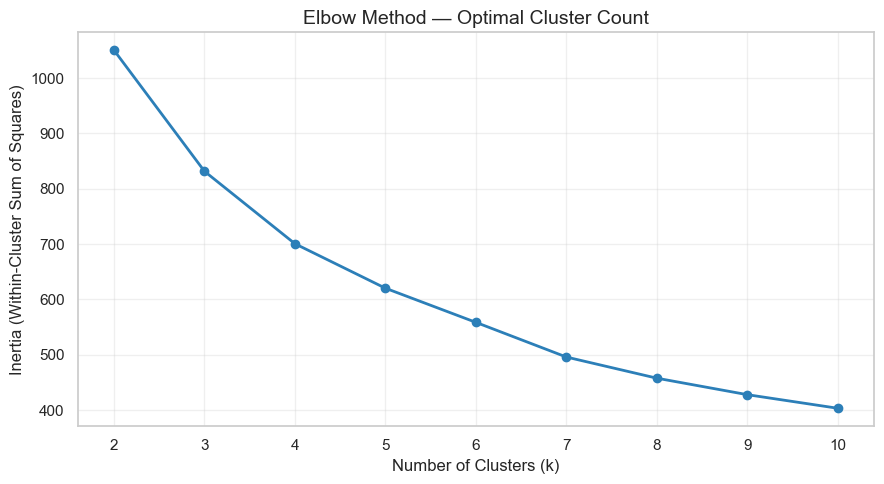

k = 2  |  inertia = 1050.21
k = 3  |  inertia = 831.42
k = 4  |  inertia = 700.52
k = 5  |  inertia = 620.16
k = 6  |  inertia = 558.47
k = 7  |  inertia = 495.81
k = 8  |  inertia = 457.59
k = 9  |  inertia = 427.80
k = 10  |  inertia = 403.23


In [10]:
wss_tracker = []
trial_range = range(2, 11)

for num_groups in trial_range:
    seg_model = KMeans(n_clusters=num_groups, random_state=42, n_init=10)
    seg_model.fit(normed_matrix)
    wss_tracker.append(seg_model.inertia_)

# plotting to find the elbow point
plt.figure(figsize=(9, 5))
plt.plot(list(trial_range), wss_tracker, marker='o', linewidth=2, color='#2c7fb8')
plt.title('Elbow Method — Optimal Cluster Count', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(trial_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k_val, wss_val in zip(trial_range, wss_tracker):
    print(f'k = {k_val}  |  inertia = {wss_val:.2f}')

## 10) Train the K-Means model

Looking at the elbow plot, k=3 is where the curve starts to flatten out noticeably.
So we go with 3 clusters and also compute the silhouette score to evaluate how well-defined they are.

In [11]:
chosen_k = 3  # picked from elbow plot

km_engine = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
country_records['kmeans_cluster'] = km_engine.fit_predict(normed_matrix)

# checking how well separated the clusters are
sil_val = silhouette_score(normed_matrix, country_records['kmeans_cluster'])
print(f'Silhouette Score for k={chosen_k}: {sil_val:.4f}')

print('\nSample cluster assignments:')
if 'country' in country_records.columns:
    display(country_records[['country', 'kmeans_cluster']].head(10))
else:
    display(country_records[['kmeans_cluster']].head(10))

Silhouette Score for k=3: 0.2833

Sample cluster assignments:


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


## 11) DBSCAN — density-based comparison

DBSCAN is interesting because it doesn't require us to pre-specify the number of clusters.
It finds groups based on density and also labels outlier points as noise (cluster = -1).
Using eps=1.5 and min_samples=5 as a starting configuration.

In [12]:
density_scan = DBSCAN(eps=1.5, min_samples=5)
country_records['dbscan_cluster'] = density_scan.fit_predict(normed_matrix)

cluster_breakdown = country_records['dbscan_cluster'].value_counts().sort_index()
print('DBSCAN cluster distribution:')
print(cluster_breakdown)

# -1 means noise/outliers in DBSCAN
actual_clusters = len([x for x in cluster_breakdown.index if x != -1])
noise_count = cluster_breakdown.get(-1, 0)
print(f'\nClusters found by DBSCAN: {actual_clusters}')
print(f'Noise points: {noise_count}')

DBSCAN cluster distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Clusters found by DBSCAN: 1
Noise points: 30


## 12) PCA visualization

We have 9 numeric features which we can't plot directly.
PCA reduces them to 2 principal components so we can see the clusters on a scatter plot.

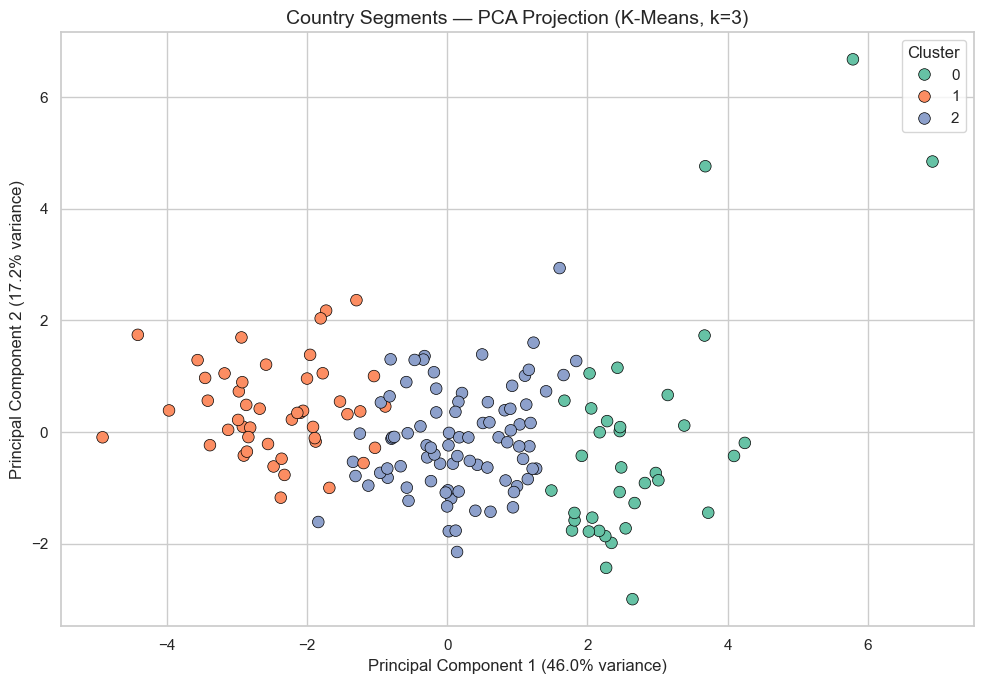

Total variance explained by 2 components: 63.1%


In [13]:
reducer = PCA(n_components=2, random_state=42)
coords_2d = reducer.fit_transform(normed_matrix)

scatter_frame = pd.DataFrame({
    'pc_one': coords_2d[:, 0],
    'pc_two': coords_2d[:, 1],
    'cluster': country_records['kmeans_cluster']
})

# color coded scatter to see how well the clusters separate in 2D
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_frame,
    x='pc_one',
    y='pc_two',
    hue='cluster',
    palette='Set2',
    s=70,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Country Segments — PCA Projection (K-Means, k=3)', fontsize=14)
plt.xlabel(f'Principal Component 1 ({reducer.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({reducer.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

total_var = sum(reducer.explained_variance_ratio_) * 100
print(f'Total variance explained by 2 components: {total_var:.1f}%')

## 13) Cluster profiling

Computing the average value of every feature within each cluster.
This is what tells us what each cluster actually represents.

In [14]:
segment_avg = country_records.groupby('kmeans_cluster')[measure_cols].mean().round(2)
display(segment_avg)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## 14) Final Observations and Insights

Now that we have the cluster profiles and the PCA plot, let's dig into what these groupings actually mean.

The questions to answer:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?

In [15]:
# listing countries per cluster to see which nations ended up where
for grp in sorted(country_records['kmeans_cluster'].unique()):
    nations_in_grp = country_records[country_records['kmeans_cluster'] == grp]['country'].values
    print(f'\n--- Cluster {grp} ({len(nations_in_grp)} countries) ---')
    print(', '.join(nations_in_grp[:20]))
    if len(nations_in_grp) > 20:
        print(f'  ... plus {len(nations_in_grp) - 20} more')

print('\n\n=== Cluster averages for reference ===')
display(segment_avg)


--- Cluster 0 (36 countries) ---
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg
  ... plus 16 more

--- Cluster 1 (47 countries) ---
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau
  ... plus 27 more

--- Cluster 2 (84 countries) ---
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China
  ... plus 64 more


=== Cluster averages for reference ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


### My Observations

**1. The High-Mortality / Underdeveloped Cluster**

One cluster stands out immediately because of its extremely high child_mort values — averaging well above 80 deaths per 1000 births, which is alarming compared to the other groups. Countries here also have very low life_expec (mid-50s to low 60s) and very high total_fer (above 5 children per woman on average). Looking at the names, we see Chad, Niger, Sierra Leone, Mali, Burkina Faso, Central African Republic and similar nations. The gdpp in this group is extremely low, often under 1000. These are the countries that need to be prioritized for humanitarian aid — the combination of high child mortality, poor healthcare spending, and minimal economic output points to deep structural problems.

**2. Top-Tier Developed Economies**

On the other end, there's a cluster with consistently low child_mort (under 10, often under 5), high life_expec (79-82 years), and high income and gdpp values running into the tens of thousands. Norway, Switzerland, Luxembourg, Australia, Canada, Denmark, Japan all fall here. Their health spending as a share of GDP is also higher than the other clusters. This cluster also has low total_fer (around 1.4-2.0), which is pretty typical for developed countries where education levels are high.

**3. The Transitioning Middle-Income Group**

The third cluster sits between the other two on basically every metric. Child_mort is moderate (roughly 15-40), life_expec is decent but not great (around 70-75), and income and gdpp fall in the mid-range. Countries like Brazil, China, Turkey, Colombia, Egypt, Indonesia, and India show up in this group. A lot of these nations have fast-growing economies and improving health outcomes, so they're kind of the "in between" segment.

**4. Inflation and Trade Don't Cleanly Separate the Clusters**

One thing I noticed is that inflation and trade metrics (exports/imports as % of GDP) don't split as cleanly between clusters as child_mort or income do. Some low-income nations have low inflation while others are extremely high (Nigeria has inflation over 100 in this dataset). Trade openness seems to depend more on a country's size and policy than its development level, so it's not a great differentiator for these clusters.

**5. PCA Scatter Plot Confirms the Separation**

The 2D PCA projection shows three fairly distinct groups, which lines up with the silhouette score. The developed nations cluster looks tight and compact on one side, while the underdeveloped cluster is more spread out — probably because there's more variation in outcomes among the poorest nations than among the wealthiest ones. The middle-income cluster sits in between, which makes sense.